Author - Vihara thejaka Kularathna


peer reviwer - Muhammad Abdullah


*   well commented explain each step
*   used the tutorial code through out the code (clear structure)


*   all three models implemented successfully

Importing the essential python libraries which needed. pandas for data manipulation, ploty for data visualization , numpy for numerical opearations and mataplot for plotting the KNN error rate

In [1]:
#import pandas for data manipulation
import pandas as pd
#importing ploty express for interative visualisation
import plotly.express as px
#importing numpy for numerical operations
import numpy as np



# Load the clasification dataset
**Seminar 1 page 13**
Loading the prepared clasification dataset which is saved from the Notebook 1

In [2]:
#loading the prepared classification dataset
df_prepared = pd.read_csv('/content/Prepared_Classification_Dataset.csv')

#displaying the first 5 rows
df_prepared.head()


,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,4,125000.0,0,1.0,4,21000,6.99,0.17,0,16,0
1,40.0,4,120000.0,2,4.0,0,20000,15.95,0.17,0,15,0
2,40.0,4,60000.0,0,13.0,2,20000,14.54,0.33,0,14,0
3,40.0,4,80000.0,2,10.0,4,20000,18.62,0.25,0,14,0
4,40.0,4,72000.0,3,3.0,2,20000,13.47,0.28,0,16,0


check the number of rows and columns in the clasification dataset

In [3]:
#check the dimensions of the dataset
df_prepared.shape

(53605, 12)

**Seminar 1 page 14**

using info confirming that all the variables are numeric after encoding in the notebook 1

In [4]:
#check the datatypes
df_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53605 entries, 0 to 53604
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       53605 non-null  float64
 1   education_qualifications  53605 non-null  int64  
 2   income                    53605 non-null  float64
 3   home_ownership            53605 non-null  int64  
 4   employment_length         53605 non-null  float64
 5   loan_intent               53605 non-null  int64  
 6   loan_amount               53605 non-null  int64  
 7   loan_interest_rate        53605 non-null  float64
 8   loan_income_ratio         53605 non-null  float64
 9   payment_default_on_file   53605 non-null  int64  
 10  credit_history_length     53605 non-null  int64  
 11  loan_approval_status      53605 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 4.9 MB


**Seminar 2 page 7**

printing the descriptive statistics to review the descriptive statistics of the classification datasset

In [5]:
df_prepared.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,53605.0,27.262724,5.849086,20.00,23.00,26.00,29.00,84.00
education_qualifications,53605.0,3.995915,0.096590,0.00,4.00,4.00,4.00,4.00
income,53605.0,57656.742922,22187.301374,4200.00,40000.00,54996.00,70000.00,126000.00
home_ownership,53605.0,1.742692,1.441934,0.00,0.00,3.00,3.00,3.00
employment_length,53605.0,4.572873,3.830623,0.00,2.00,4.00,7.00,150.00
loan_intent,53605.0,2.515903,1.724839,0.00,1.00,3.00,4.00,5.00
loan_amount,53605.0,8492.876635,4570.299402,500.00,5000.00,8000.00,12000.00,22500.00
loan_interest_rate,53605.0,10.667392,3.273318,-11.14,7.88,10.74,12.99,200.00
loan_income_ratio,53605.0,0.159201,0.088894,0.00,0.09,0.14,0.21,0.83
payment_default_on_file,53605.0,0.148512,0.355610,0.00,0.00,0.00,0.00,1.00


# Visualize the target variable
**Seminar 4 page 2**

**plotting a histogram for the loan approval status which is the target variable**

In [6]:
#visualizing the distribution of the target variable
approval_fig = px.histogram(df_prepared, x='loan_approval_status',
                             title='Distribution of Loan Approval Status (0=Approved, 1=Declined)')
approval_fig.show()

# Assignning input features (X) and target variable (Y)
**Seminar 4 page 6**

Assigning x and y seprate the dataset into input features x by dropping the target column and assign the target variable loan appoval status to y using drop()

In [7]:
#creating a datafram with all input features except the target column
X = df_prepared.drop(columns=['loan_approval_status'])
#target variable for modeling - loan approval status
y = df_prepared['loan_approval_status']
#checking the list of input variable
list(X)

['age',
 'education_qualifications',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length']

In [8]:
#first 5 values of the target variable
y.head()

,loan_approval_status
0,0
1,0
2,0
3,0
4,0


# Scaling the input feature
**Seminar 3 page 8**

Applying standard scaler for standarise all the input features for have zero mean and unit variabce. using fit_transform()

In [9]:
#importing standarrd scaler
from sklearn.preprocessing import StandardScaler
#creating a standard scaler
scaler = StandardScaler()
#putting standard scaling to the input features
X1 = scaler.fit_transform(X)
#displaying the scale features
X1

array([[ 2.17767258,  0.04229711,  3.03524453, ...,  0.12148673,
        -0.41763026,  2.63605298],
       [ 2.17767258,  0.04229711,  2.8098883 , ...,  0.12148673,
        -0.41763026,  2.38148954],
       [ 2.17767258,  0.04229711,  0.10561352, ...,  1.92139586,
        -0.41763026,  2.1269261 ],
       ...,
       [ 1.32283022,  0.04229711,  1.68310714, ..., -1.34093944,
        -0.41763026,  1.10867234],
       [ 0.29701939,  0.04229711,  2.58453207, ..., -1.34093944,
        -0.41763026,  1.10867234],
       [ 0.46798786,  0.04229711,  2.50417004, ..., -1.00345647,
        -0.41763026,  0.8541089 ]])

Split the scale dataset into 75% trainning and 25% test substes with using train_test_split() with random_state=0 for ensure reproductabiity.

In [10]:
#importing train test split
from sklearn.model_selection import train_test_split
#spliting out the data into train and for the test subsets
X1_train, X1_test, y_train, y_test = train_test_split(X1, y,
                                                    test_size=0.25,
                                                    random_state=0)






In [11]:
print('dataset shape', df_prepared.shape)
print('x1 train shape', X1_train.shape)
print('x1 test shape', X1_test.shape)

dataset shape (53605, 12)
x1 train shape (40203, 11)
x1 test shape (13402, 11)


In [12]:
#calculating the total number of instances in the training and test sets
total_train = len(y_train)
total_test = len(y_test)
#counting the number of approved applicant in the trainning set
approved_train = len(y_train[y_train==0])
#counting the number of declined applicant in the trainning set
declined_train = len(y_train[y_train==1])
#counting the number of approved applicant in the test set
approved_test = len(y_test[y_test==0])
#counting the number of declined applicant in the test set
declined_test = len(y_test[y_test==1])
#calculating the percentage ratio of the approved approved applicant in the trainning set
ratio_approved_train = (approved_train/total_train)*100
#calculating the percentage ratio of the declined applicant in the training set
ratio_declined_train = (declined_train/total_train)*100
#calculating the percentage ratio of approved applicant in the test set
ratio_approved_test = (approved_test/total_test)*100
#calculating the percentage ratio of declined applicant in the test set
ratio_declined_test = (declined_test/total_test)*100

print('Training set - Approved:', approved_train, 'Declined:', declined_train)
print('Training set ratios - Approved%:', ratio_approved_train, 'Declined%:', ratio_declined_train)
print('Test set - Approved:', approved_test, 'Declined:', declined_test)
print('Test set ratios - Approved%:', ratio_approved_test, 'Declined%:', ratio_declined_test)



Training set - Approved: 34428 Declined: 5775
Training set ratios - Approved%: 85.63540034325796 Declined%: 14.364599656742033
Test set - Approved: 11482 Declined: 1920
Test set ratios - Approved%: 85.67378003283093 Declined%: 14.326219967169079


# Model 1 - Logisitic Regression
**Seminar 3 page 9**

instantiates and fit the logistic regression classifier using the default parameters on the trainning data and performing thr prediction on the test data.

In [13]:
#importing the logisitic regression class
from sklearn.linear_model import LogisticRegression
#instantiate the model
logreg = LogisticRegression()
#fiting out the model on trainning data
logreg.fit(X1_train, y_train)
#performing out the predicions in the test data
y_pred_lr = logreg.predict(X1_test)

**Seminar 3 page 10**

calculate and printing the accuracy score of the logistic regression model on the test set using accuracy_score()

In [14]:
#importing aacuracy score for evaluating the model performane
from sklearn.metrics import accuracy_score
#calculating the accuracy for the logisic regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
#displaying the accuracy
print ("Logisitc regression Model Accuracy -" , accuracy_lr)


Logisitc regression Model Accuracy - 0.889344873899418




**Seminar 3 page 10**

construct and plots a confusion matrix for the logistic regression model for show the number of correcrt and incorrect predictions for the each class.



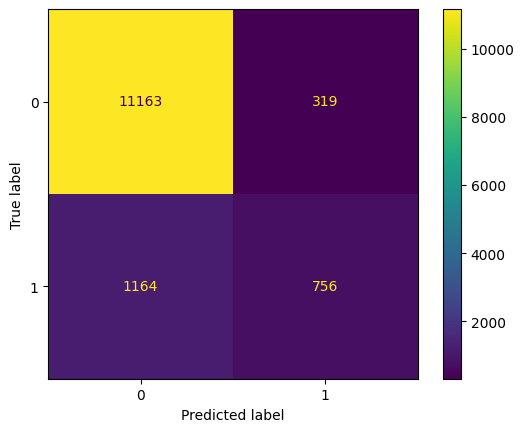

In [15]:
#importing packages for the confusion metrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#making the confusion matrix for the logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
#making the display to plotting the confusion matrix
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=logreg.classes_)
disp_lr.plot()

**Seminar 3 page 11**

Clasification report for the logisitic regression model prints precision, recall, and f1 score for each class

In [16]:
#importing clasification report
from sklearn.metrics import classification_report
#clasification report for the logistic regression
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     11482
           1       0.70      0.39      0.50      1920

    accuracy                           0.89     13402
   macro avg       0.80      0.68      0.72     13402
weighted avg       0.88      0.89      0.88     13402



**Seminar 3 page 11**

Roc curve visualse the trade off between true positive rate and false positive rate

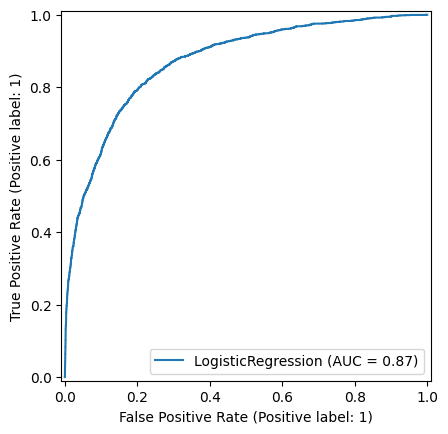

In [17]:
#importing RocCurve Display
from sklearn.metrics import RocCurveDisplay

#plotting out ROC curve for logisitic regression
logreg_roc = RocCurveDisplay.from_estimator(logreg, X1_test, y_test)


# Model 2 - Naive Bayes
**Seminar 4 page 15**

instantiates and fits a gaussian Naives bayes classifier on the trainning data and performing prediction on test data



In [18]:
#import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

#instanaing Naive Bayes model
nb = GaussianNB()

#fiting the model for trainning data
nb.fit(X1_train, y_train)

# predicting on test data
y_pred_nb = nb.predict(X1_test)

Calculating the accuracy and prints the accuracy score of the NB model on test set data

In [19]:
#finding the accuracy of the NB model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
#display accuracy
print('NB model Accuracy:', accuracy_nb)

NB model Accuracy: 0.8598716609461274


**Seminar 4 page 15**

genarates and plots the confusion matrix for the NB model

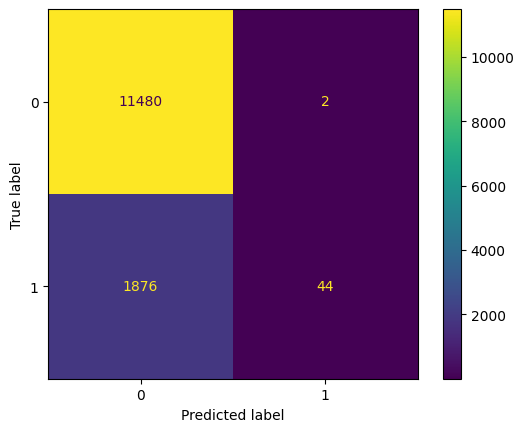

In [20]:
#making the confusion maric for NB
nb_cm = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
#making a display plot for he NB
disp_nb = ConfusionMatrixDisplay(nb_cm, display_labels=nb.classes_)
disp_nb.plot()

**Seminar 4 page 15**

printing the clasification report for Naive bayes model which shows precision, recall, and f1 score

In [21]:
#printing the clasification report for NB
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     11482
           1       0.96      0.02      0.04      1920

    accuracy                           0.86     13402
   macro avg       0.91      0.51      0.48     13402
weighted avg       0.87      0.86      0.80     13402



**Seminar 4 page 16**

plotting thr ROC curve for naive bayes model

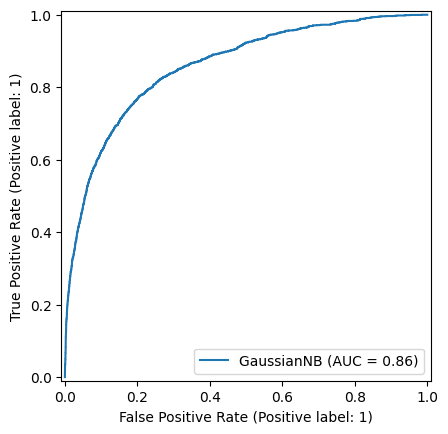

In [22]:
#plotting the RoC curve for NB
nb_roc = RocCurveDisplay.from_estimator(nb, X1_test, y_test)

# Model 3 - K-Nearest Neighbours (KNN)
**Seminar 4 page 7**


instantiates and fit a K nearest neighbours classifies with k=9 as the starting point of the trainning data performing the predictions on the test data

In [23]:
#import KNeighbourC;assofoer
from sklearn.neighbors import KNeighborsClassifier

#making a KNN classifier k=9
knn = KNeighborsClassifier(n_neighbors=9)

#fitting out the classifier into trainning data
knn.fit(X1_train, y_train)

# predicting  on test data
y_pred_knn = knn.predict(X1_test)

calculating the accuracy score for the KNN model with k=9

In [24]:
#calculating the accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
#printing the accuracy
print(' KNN Model Accuracy:', accuracy_knn)

 KNN Model Accuracy: 0.9101626622892106


**Seminar 4 page 8**

constructs and plotting the confusion matric for the KNN model

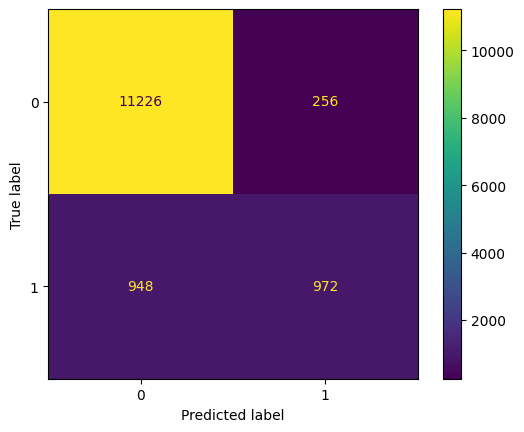

In [25]:
#creating the confusion metrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
#display the KNN confusion metrix
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)

disp_knn.plot()

**Seminar 4 page 8**

printing the clasification report for KNN which showing precision, Recall and f1 score

In [26]:
#classfication report for KNN
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     11482
           1       0.79      0.51      0.62      1920

    accuracy                           0.91     13402
   macro avg       0.86      0.74      0.78     13402
weighted avg       0.90      0.91      0.90     13402



**Seminar 4 page 8**

Plotting the ROC curve for the KNN model

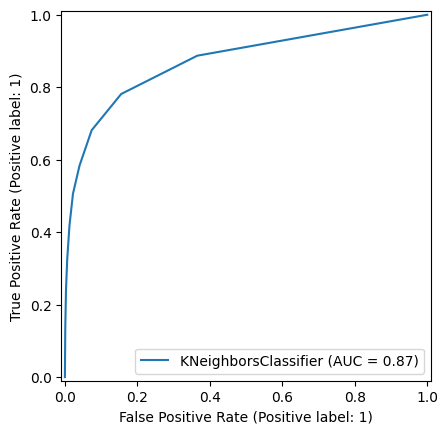

In [27]:
#plotting out the roc curve for knn
knn_roc = RocCurveDisplay.from_estimator(knn, X1_test, y_test)

**Seminar 4 page 9**

buliding 39 KNN models with k values from 1 to 39 and showing the mean error rate for each K  value to identify the optimal K which produces the lowest prediction error

Text(0, 0.5, 'Mean Error')

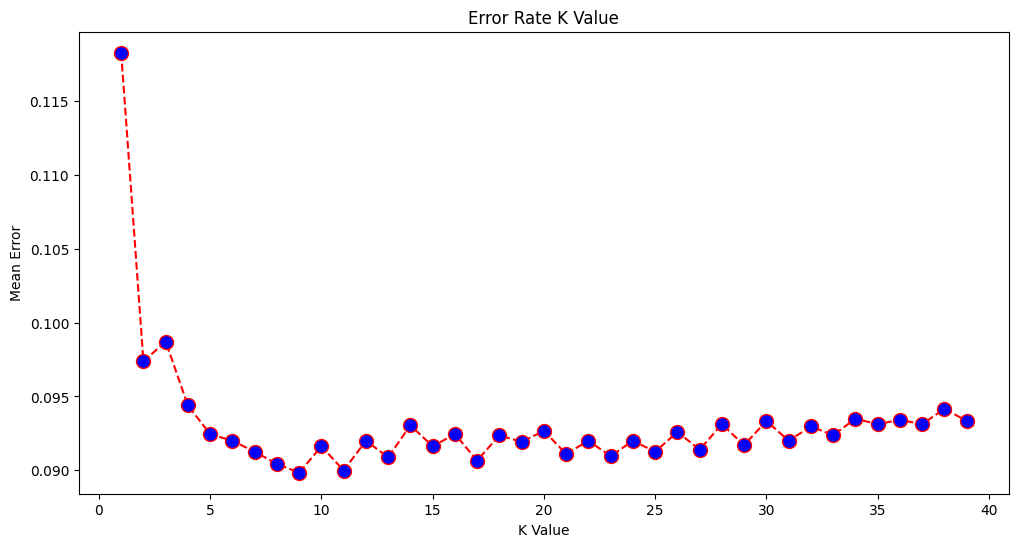

In [28]:
#calculating the error values within 1 and 40 for finding out the optimal k value for KNN
error = []

import matplotlib.pyplot as plt

#calculating for the k values between 1 and 40
for i in range(1, 40):
      knn2 = KNeighborsClassifier(n_neighbors=i)
      knn2.fit(X1_train, y_train)
      pred_i = knn2.predict(X1_test)
      error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')


# KNN with optimal k value
**Seminar 4 page 9**

rebuilding the KNN model with optimal k value which same as the previous model k=9

In [29]:
#building knn with optimal k value
knn1 = KNeighborsClassifier(n_neighbors=9)
#fiting the improved knn for trainning data
knn1.fit(X1_train, y_train)
#finding predictions on the test data
y_pred_knn1 = knn1.predict(X1_test)

Finding the accuracy score for the KNN model with optimal K value

In [30]:
#accuracy report for knn with the optimal value
accuracy_knn1 = accuracy_score(y_test, y_pred_knn1)
print(' KNN Model Accuracy tuned:', accuracy_knn1)

 KNN Model Accuracy tuned: 0.9101626622892106


**Seminar 4 page 10**

plotting tge confusion matrix for the imrpved KNN model with optimal K

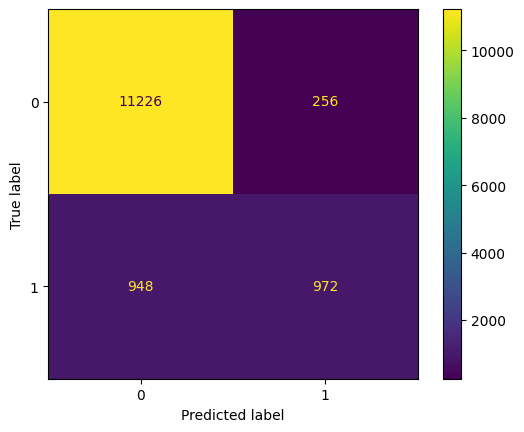

In [31]:
#confusion metrix for the improves knn model
cm_knn1 = confusion_matrix(y_test, y_pred_knn1, labels=knn1.classes_)
#creating the metrix
disp_knn1 = ConfusionMatrixDisplay(cm_knn1, display_labels=knn1.classes_)

disp_knn1.plot()

**Seminar 4 page 10**

printing the clasification report for improved KNN model

In [32]:
#clasification report for KNN witht the optimal value
print(classification_report(y_test, y_pred_knn1))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     11482
           1       0.79      0.51      0.62      1920

    accuracy                           0.91     13402
   macro avg       0.86      0.74      0.78     13402
weighted avg       0.90      0.91      0.90     13402



**Seminar 4 page 10**

Plots the ROC curve for the Improved KNN model with the optimal K value

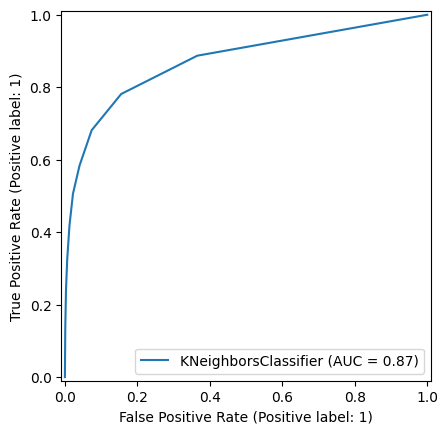

In [33]:
#ROC curve for KNN optimal value
knn1_roc = RocCurveDisplay.from_estimator(knn1, X1_test, y_test)

**Seminar 3 page 10**

compares the accuracy scores of all three models

In [34]:
#printing the accuracy for 3 models
lr_acc = accuracy_score(y_test, y_pred_lr)
nb_acc = accuracy_score(y_test, y_pred_nb)
knn_acc = accuracy_score(y_test, y_pred_knn1)

In [35]:
print('Logistic Regression Accuracy:', lr_acc)
print('Naive Bayes Accuracy:        ', nb_acc)
print('KNN Accuracy (optimal k):    ', knn_acc)

Logistic Regression Accuracy: 0.889344873899418
Naive Bayes Accuracy:         0.8598716609461274
KNN Accuracy (optimal k):     0.9101626622892106


# GridSearchCV
**Seminar 4 page 11**

Creating a parameter grid of n_neighbours values from 1 to 24 and two distance mertics
euclidean', 'manhattan
applies gridsearchCV with 5 fold cross validation for finding optimal combination of hyprparamters for the KNN model.

In [36]:
#importing gridsearchCv
from sklearn.model_selection import GridSearchCV
#making a new knn model for grid search
knn = KNeighborsClassifier()
#making dictonery with all values to test n_neighbours and distance metrics
param_grid = {'n_neighbors': np.arange(1, 25),
               'metric': ['euclidean', 'manhattan']}
#use grid search to test all values for n_neighbours
knn_gscv = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')
#fit model to data
knn_gscv.fit(X1, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

**Seminar 4 page 12**

Printing the best hypeparamters found by GridsearchCV using best_params_

In [37]:
#checking top performing n neighbour values
knn_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(24)}

**Seminar 4 page 12**

In [38]:
#perform testting on test data
y_pred_gscv = knn_gscv.predict(X1_test)

**Seminar 4 page 12**

constructing the confusion metrix / clasification report to evaluate the optimised model performace

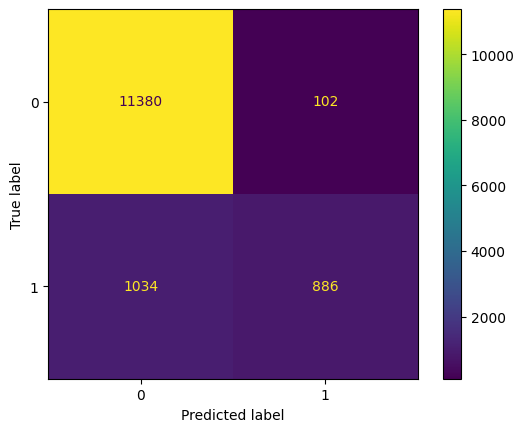

In [39]:
#constructing a confusion metrix
cm_knn_gscv = confusion_matrix(y_test, y_pred_gscv,
                                labels=knn_gscv.classes_)

disp_knn_gscv = ConfusionMatrixDisplay(cm_knn_gscv,
                                        display_labels=knn_gscv.classes_)
disp_knn_gscv.plot()

**Seminar 4 page 12**

In [40]:
#printing the clasification report for the tuned model
print(classification_report(y_test, y_pred_gscv))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     11482
           1       0.90      0.46      0.61      1920

    accuracy                           0.92     13402
   macro avg       0.91      0.73      0.78     13402
weighted avg       0.91      0.92      0.90     13402



**Seminar 4 page 12**

Plotting the ROC curve for the hyperparamter tuned KNN model

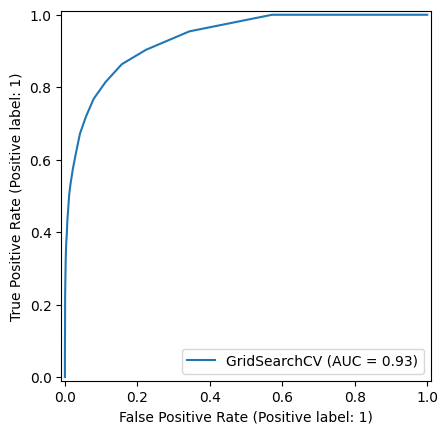

In [41]:
#ROC curve for tuned model
knn_gscv_roc = RocCurveDisplay.from_estimator(knn_gscv, X1_test, y_test)

Comparing the accuracy of the tuned model and original best model

In [42]:
print('original best model accuracy:', knn_acc)
print('tuned model Accuracy:        ', accuracy_score(y_test, y_pred_gscv))


original best model accuracy: 0.9101626622892106
tuned model Accuracy:         0.9152365318609162


**Seminar 3 page 7**

creates a comparision dataframe of actual vs predicted loan approval status values for the tuned model and save it in the CSV filr format

In [43]:
#creating comparisson dataframe which showing actual vs prediction
Comparison_df = pd.DataFrame({'Actual Loan Approval Status': y_test,
                               'Predicted': y_pred_gscv})
#saving the comaprison results to a CSv file
Comparison_df.to_csv(r'/content/Classification_Comparison_df.csv', index=True)
#displaying the comparision dataframe
Comparison_df

,Actual Loan Approval Status,Predicted
27143,0,0
7230,1,0
27554,0,0
45493,0,0
9881,0,0
...,...,...
42685,0,0
24656,0,0
14261,0,0
39961,0,0
